# Projekt 2 – Segmentacja Tęczówki


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from iris_segmentation import IrisSegmentation

iris = IrisSegmentation()

## 1. Wczytanie obrazu

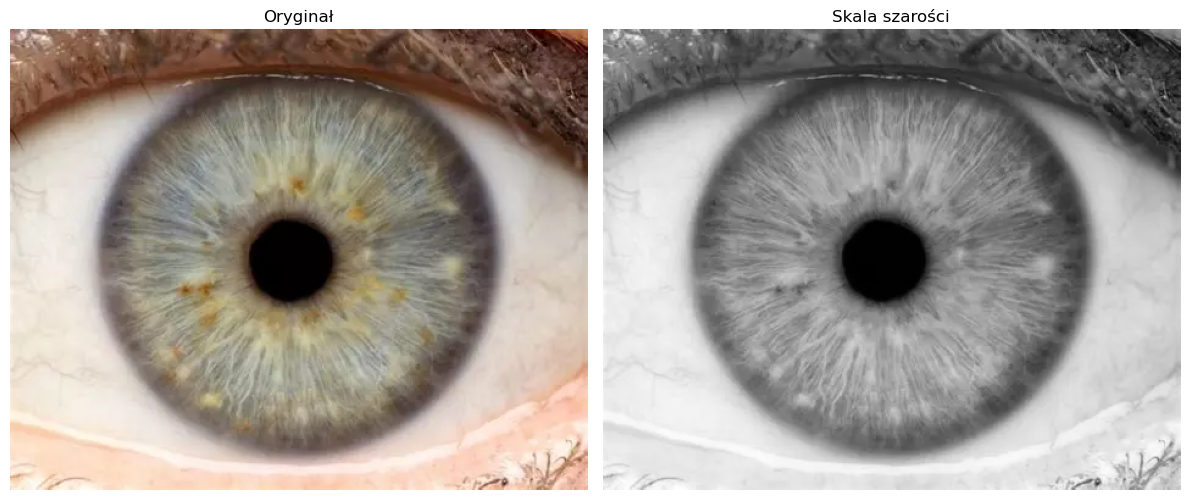

Wymiary: (474, 378)  |  Średnia jasność P = 149.46


In [ ]:
IMAGE_PATH = "eye3.webp"   

image = Image.open(IMAGE_PATH)
gray_arr = iris._to_gray(image)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title('Oryginał')
axes[1].imshow(gray_arr, cmap='gray')
axes[1].set_title('Skala szarości')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

P = iris._mean_brightness(gray_arr)
print(f'Wymiary: {image.size}  |  Średnia jasność P = {P:.2f}')

## 2. Binaryzacja z progiem P/X
$$P_P = \frac{P}{X_P}, \qquad P_I = \frac{P}{X_I}$$
Parametry `X_PUPIL` i `X_IRIS` dobieramy eksperymentalnie.

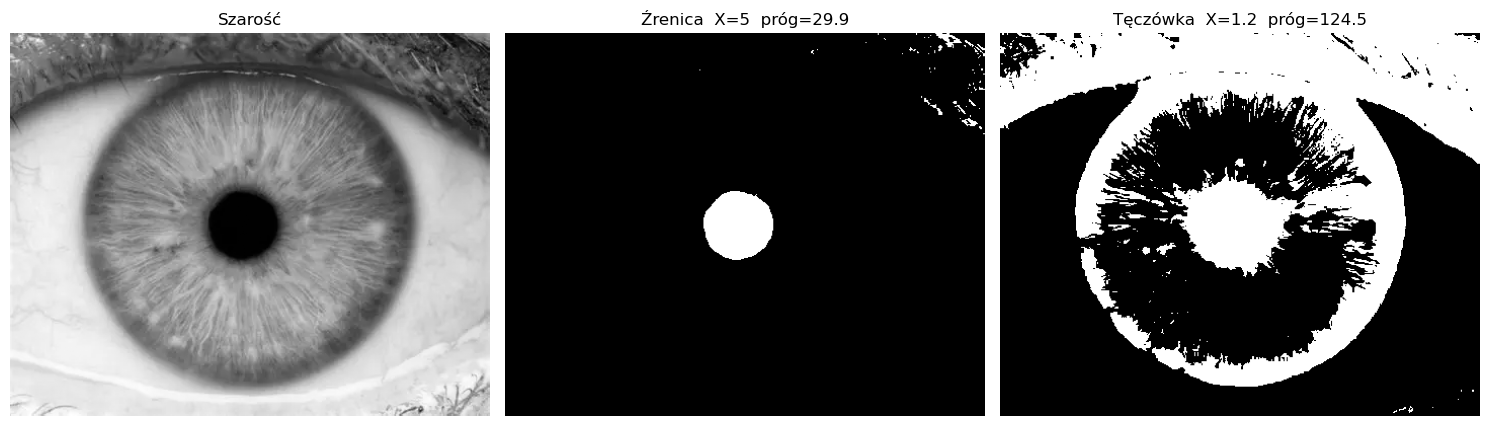

In [ ]:
X_PUPIL = 5  # próg źrenicy
X_IRIS  = 1.2   # próg tęczówki

bin_pupil = iris.binarize_px(image, X_PUPIL)
bin_ir    = iris.binarize_px(image, X_IRIS)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_arr, cmap='gray')
axes[0].set_title('Szarość')
axes[1].imshow(bin_pupil, cmap='gray')
axes[1].set_title(f'Źrenica  X={X_PUPIL}  próg={P/X_PUPIL:.1f}')
axes[2].imshow(bin_ir, cmap='gray')
axes[2].set_title(f'Tęczówka  X={X_IRIS}  próg={P/X_IRIS:.1f}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Morfologia – czyszczenie maski źrenicy

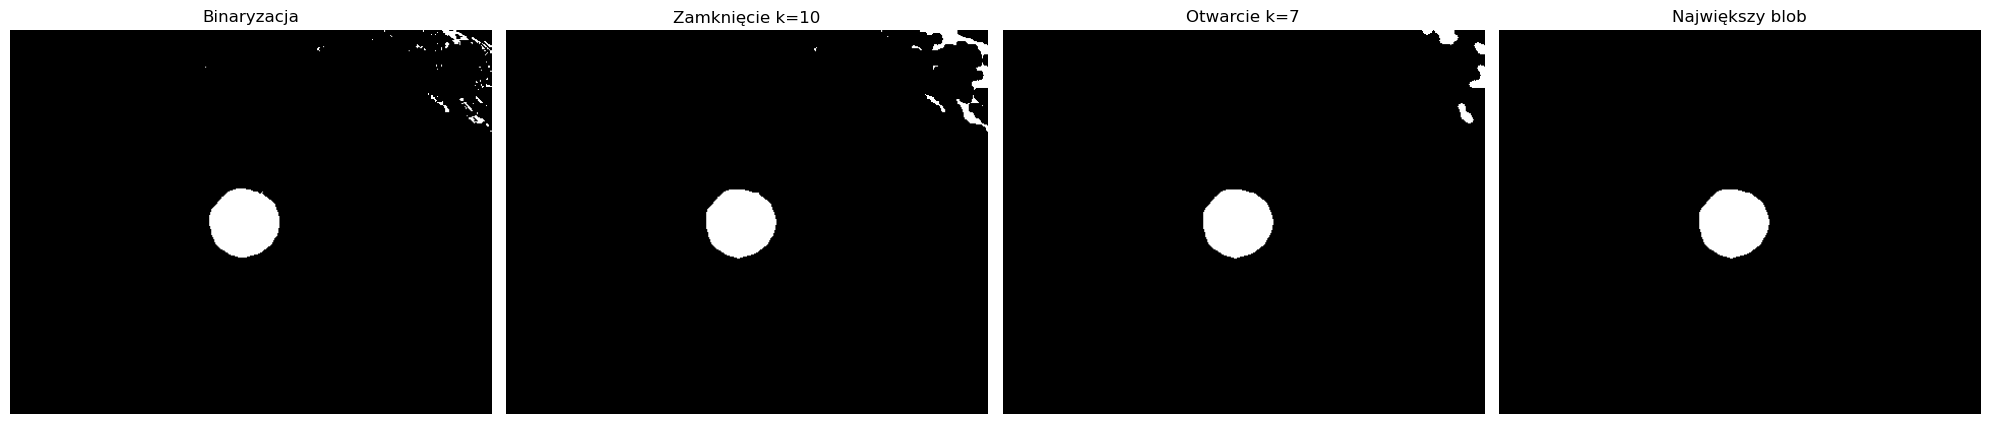

In [ ]:
CLOSE_SIZE = 10   # zamknięcie 
OPEN_SIZE  = 7    # otwarcie   

bin_closed = iris._morph_close(bin_pupil, CLOSE_SIZE, 'ellipse')
bin_opened = iris._morph_open(bin_closed, OPEN_SIZE,  'ellipse')
bin_clean  = iris._keep_largest_blob(bin_opened)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, title in zip(axes,
    [bin_pupil, bin_closed, bin_opened, bin_clean],
    ['Binaryzacja', f'Zamknięcie k={CLOSE_SIZE}', f'Otwarcie k={OPEN_SIZE}', 'Największy blob']):
    ax.imshow(img, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Projekcje → środek i promień źrenicy

Środek: (230, 189)  |  Promień źrenicy: 33 px


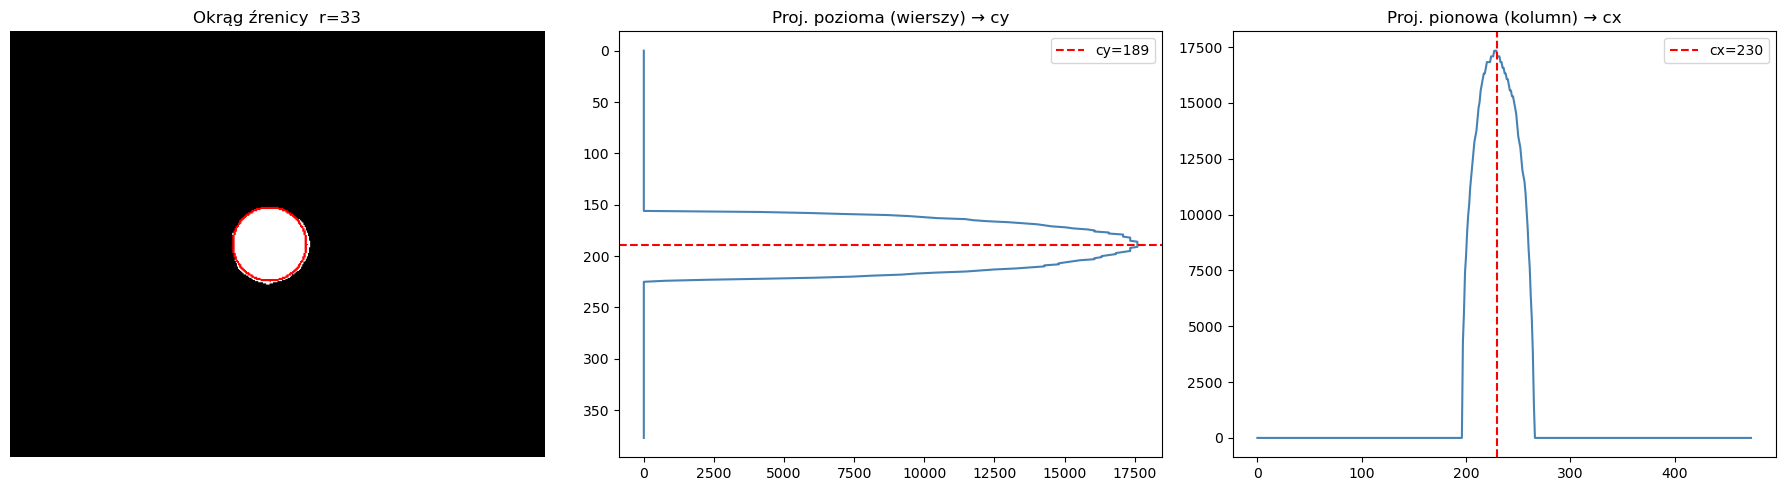

In [ ]:
cx, cy, pupil_r = iris._detect_circle_projection(bin_clean)
print(f'Środek: ({cx}, {cy})  |  Promień źrenicy: {pupil_r} px')

proj_rows = bin_clean.sum(axis=1) # Profil Y (wysokość)
proj_cols = bin_clean.sum(axis=0) # Profil X (szerokość)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Obraz z okręgiem
overlay = np.stack([bin_clean]*3, axis=-1).copy()
overlay = iris._draw_circle(overlay, cx, cy, pupil_r, (255, 0, 0), 2)
axes[0].imshow(overlay)
axes[0].set_title(f'Okrąg źrenicy  r={pupil_r}')
axes[0].axis('off')

# 2. Projekcja pozioma (wiersze) -> szukanie cy
# Używamy proj_rows. Oś Y wykresu to wysokość obrazu.
axes[1].plot(proj_rows, range(len(proj_rows)), color='steelblue')
axes[1].axhline(cy, color='red', linestyle='--', label=f'cy={cy}')
axes[1].invert_yaxis() 
axes[1].set_title('Proj. pozioma (wierszy) → cy')
axes[1].legend()

# 3. Projekcja pionowa (kolumny) -> szukanie cx
# Używamy proj_cols. Oś X wykresu to szerokość obrazu.
axes[2].plot(proj_cols, color='steelblue') 
axes[2].axvline(cx, color='red', linestyle='--', label=f'cx={cx}')
axes[2].set_title('Proj. pionowa (kolumn) → cx')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Detekcja promienia tęczówki

Promień tęczówki: 116 px


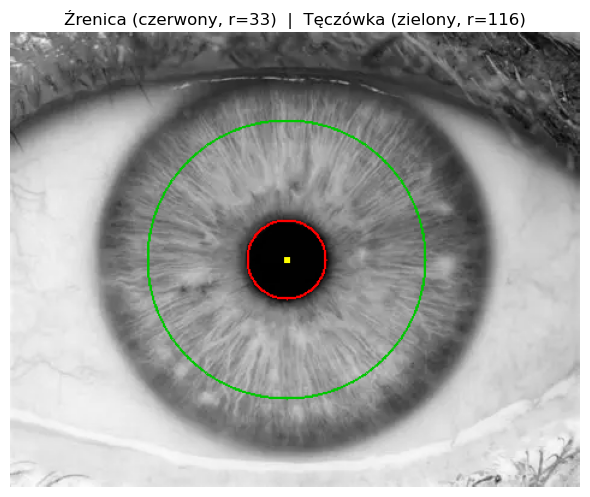

In [ ]:
iris_r = iris._detect_iris_radius(gray_arr, cx, cy, pupil_r, X_IRIS) 
print(f'Promień tęczówki: {iris_r} px')

overlay2 = np.stack([gray_arr]*3, axis=-1).copy()
overlay2 = iris._draw_circle(overlay2, cx, cy, pupil_r, (255, 0,   0), 2)
overlay2 = iris._draw_circle(overlay2, cx, cy, iris_r,  (0,   200, 0), 2)
overlay2[cy-2:cy+3, cx-2:cx+3] = (255, 255, 0)

plt.figure(figsize=(6, 6))
plt.imshow(overlay2)
plt.title(f'Źrenica (czerwony, r={pupil_r})  |  Tęczówka (zielony, r={iris_r})')
plt.axis('off'); plt.tight_layout(); plt.show()

## 6. Rozwinięcie tęczówki do prostokąta


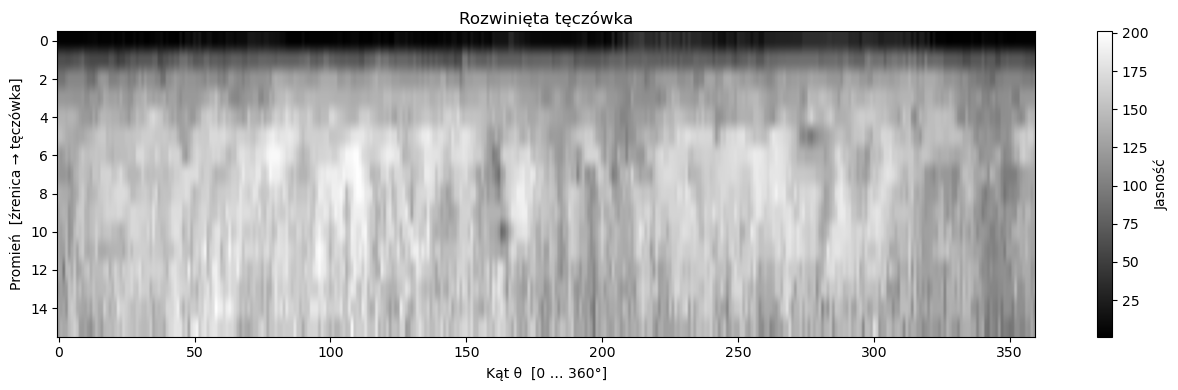

Rozmiar: (16, 360)  (radial × angular)


In [ ]:
RADIAL_RES  = 16
ANGULAR_RES = 360

unwrapped = iris.unwrap_iris(gray_arr, cx, cy, pupil_r, iris_r, RADIAL_RES, ANGULAR_RES)

plt.figure(figsize=(13, 4))
plt.imshow(unwrapped, cmap='gray', aspect='auto')
plt.title('Rozwinięta tęczówka')
plt.xlabel('Kąt θ  [0 … 360°]')
plt.ylabel('Promień  [źrenica → tęczówka]')
plt.colorbar(label='Jasność')
plt.tight_layout(); plt.show()
print(f'Rozmiar: {unwrapped.shape}  (radial × angular)')

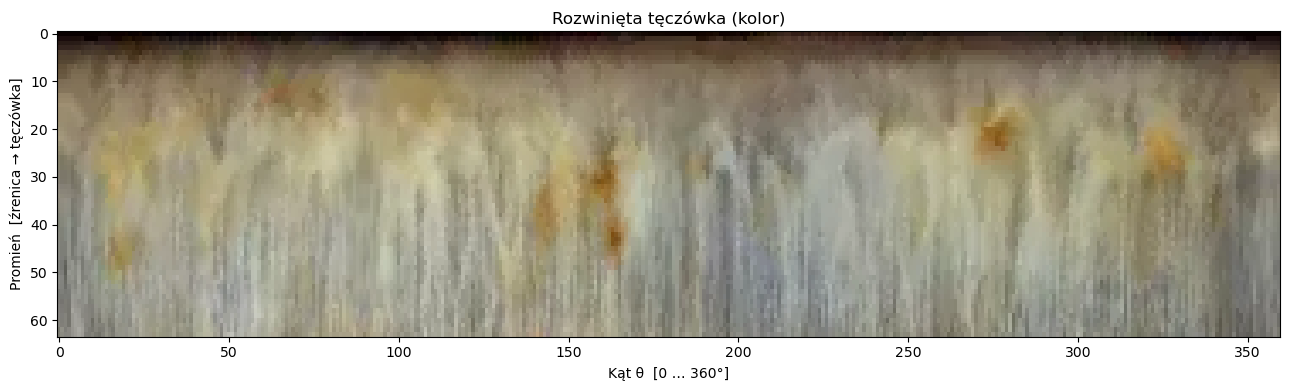

Rozmiar: (64, 360, 3) (radial × angular × kanały koloru)


In [ ]:
RADIAL_RES  = 64
ANGULAR_RES = 360

# Pobieramy oryginalny kolorowy obraz w postaci tablicy numpy
color_arr = np.array(image)

# Rozwijamy każdy kanał (Red, Green, Blue) osobno
unwrapped_R = iris.unwrap_iris(color_arr[:, :, 0], cx, cy, pupil_r, iris_r, RADIAL_RES, ANGULAR_RES)
unwrapped_G = iris.unwrap_iris(color_arr[:, :, 1], cx, cy, pupil_r, iris_r, RADIAL_RES, ANGULAR_RES)
unwrapped_B = iris.unwrap_iris(color_arr[:, :, 2], cx, cy, pupil_r, iris_r, RADIAL_RES, ANGULAR_RES)

# Łączymy trzy czarno-białe rozwinięcia w jedno kolorowe (stack)
unwrapped_color = np.stack([unwrapped_R, unwrapped_G, unwrapped_B], axis=-1)

# Upewniamy się, że wartości pikseli mieszczą się w standardowym zakresie (0-255)
unwrapped_color = np.clip(unwrapped_color, 0, 255).astype(np.uint8)

plt.figure(figsize=(13, 4))
# Ważne: usuwamy argument cmap='gray', by wyświetlić kolory
plt.imshow(unwrapped_color, aspect='auto') 
plt.title('Rozwinięta tęczówka (kolor)')
plt.xlabel('Kąt θ  [0 … 360°]')
plt.ylabel('Promień  [źrenica → tęczówka]')
plt.tight_layout()
plt.show()

print(f'Rozmiar: {unwrapped_color.shape} (radial × angular × kanały koloru)')

## 7. Cały pipeline jedną komendą

In [ ]:
result = iris.segment(
    image,
    X_pupil=X_PUPIL,
    X_iris=X_IRIS,
    close_size_pupil=CLOSE_SIZE,
    open_size_pupil=OPEN_SIZE,
    radial_res=RADIAL_RES,
    angular_res=ANGULAR_RES,
    verbose=True
)

result_img = iris.draw_result(image, result)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Segmentacja tęczówki – wyniki', fontsize=13)
data = [
    (result['gray'],               'gray', 'Szarość'),
    (result['binary_pupil'],       'gray', 'Binaryzacja\nźrenicy'),
    (result['binary_pupil_clean'], 'gray', 'Maska źrenicy\n(po morfologii)'),
    (np.array(result_img),         None,   'Detekcja okręgów'),
    (result['unwrapped'],          'gray', 'Rozwinięta\ntęczówka'),
]
for ax, (img, cmap, title) in zip(axes, data):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('segmentation_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Zapisano: segmentation_result.png')

[INFO] Nakładanie autorskiego filtra Gaussa (to może chwilę potrwać...)


AttributeError: 'IrisSegmentation' object has no attribute 'gaussian_filter'